## Enhancing Public Safety: A Comprehensive Analysis of Geospatial Shifts in Los Angeles and Prediction of Crime Volatility for LAPD Deployment

### Team
Our team, Treeo, consists of three members:
- Ashley Rauch will act as the POC for the group - ashrauch4
- Madeyln Forster - mgforste
- Brealin Redecker - brealinredecker

### Overview
Our crime reporting dataset reflects all incidents of crime in the City of Los Angeles dating back to 2020, collected by The Los Angeles Police Department (LAPD). Ensuring the safety of the public is a fundamental responsibility of the government. Crime, of all levels, can lead to loss of life, physical injury, and significant economic and social impacts on individuals and communities. While a certain level of crime may be considered inevitable, we aim to uncover structural shifts in crime patterns and build a tool that predicts crime volatility and potential "hotspots". The tool will enable the LAPD to develop evidence-based strategies for deployment of its forces as there is a finite number of patrol units available. 

Most crime prediction models explore static relationships, such as linking demographic data to crime rates. These approaches of predictive policing tend to reinforce overpolicing in areas that already get heavy surveillance. Hence, historical "hotspots" are not enough and dismiss crucial aspects of racial biases, current deployment, and accuracy in crime reporting. Long term, instead of just predicting emerging high-volatility crime areas, we are framing it as a deployment question: where should the LAPD actually field its forces? Shifting our focus slightly was important as currently, areas with less police presence result in fewer crime reportings and vice versa, so a model trained only on reported data will keep sending resources to the same places and neglecting everywhere else. We hope to bring in additional data on historical deployment, demographic information on the area, and/or NYC crime data to perform a comparative analysis. Furthermore, we plan to build in an adjustment that estimated how police presence affects the likelihood that a crime actually gets reported and checks against over-concentration and setting minimum coverage thresholds so no area gets completely ignored.

As briefly mentioned, the primary stakeholder for this project is the LAPD. The LAPD are responsible for public safety, and crime incidents are a major public safety concern as they aim to reduce the number of crimes in the areas they police. Success in this project will make two main differences:
1. Ensure resources don't just get locked in historical patterns.
2. Distinguish table high-crime zones from emergencying high-volatility areas so police forces can be adequately deployed.

Overall, our approach and specific needs have not changed. Our team, though, has done some deeper thinking on how we can incorporate other data to improve our model from just predicting hotspots.

### Data
Link to Data: "https://catalog.data.gov/dataset/crime-data-from-2020-to-present"

Our project will utilize data from 'data.gov' and is a crime data set that gives crime information from 2020-Present in Los Angeles. The data has 28 columns, a combination of string, integer, and float features, with over a million rows of data. As the data is government data, it must be accurate, ensuring it is reliable for model use. Also, according to the Freedom of Information Act, they are legally obligated to disclose information — including crime data and records of misconduct — under public records laws. The data includes meta deta, such as that it was published by the Los Angeles Police Department (LAPD), it is publically available data, and it was last updated on January 2, 2026. Some additional aspects we have noted will impact our model, though, is the data is noisy and the specific times when and where crimes get reported versus logged is not always reliable. Many times they will be inputted into the system at the location of the police station in batches of times - this unknown, while can't be changed, needs to be considered when analyzing the model.

### Preprocessing
Our dataset was large, so transformed the raw administrative logs into a clean dataset that is suitable for predicting geospatial volatility. First, we filtered the dataframe to only include crime codes corresponding to assaults, narrowing our scope to high-impact public safety incidents. Next, we addressed data sparsity by dropping columns with over 80% null values. Specifically, we removed "Crm Cd 2", "Crm Cd 3" and "Crm Cd 4" columns as the data was being captured in the "Crm Cd" and "Crm Cd 1" columns. We also removed "Cross Street" as there was a high null percentage and there are other columns to capture the location. This was done to optimize our model's computational efficiency without losing primary intent. Moreover, we transformed the "Date Rptd", "DATE OCC", and "TIME OCC" columns into standardized temporal objects which would allow us to extract cyclical features in our analysis. To ensure we had high quality data for our spatial grid model, we removed invalid coordinates and any entries with missing spatial metadata. Finally, to prepare categorical features for our models, we implemented One-Hot Encoding for victim demographics, and the code-snippet can be seen below. Our group used this cleaned dataset to explore distributions and patterns.

In [6]:
%%capture
'''
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
vict_sex_encoded = encoder.fit_transform(df_filtered[['Vict Sex']].fillna('Unknown'))

df_one_hot = pd.DataFrame(
    vict_sex_encoded, 
    columns=encoder.get_feature_names_out(['Vict Sex']),
    index=df_filtered.index # Important: keeps the rows aligned!
)
'''

### Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

# Load in the data
data = pd.read_csv("LA_Assault_Data_2020_Present.csv")

First we examined the proportional distribution of specific assault categories within our filtered dataset. There are many categories and severities of assault in our dataset, so this step allowed us to determine the baseline frequency of each crime type and distinguish between chronic, low-level incident areas and severe, violent areas. Battery - Simple Assault, ADW/Aggravated Assault, and Spousal Abuse (Simple) make up most of the assault crimes.

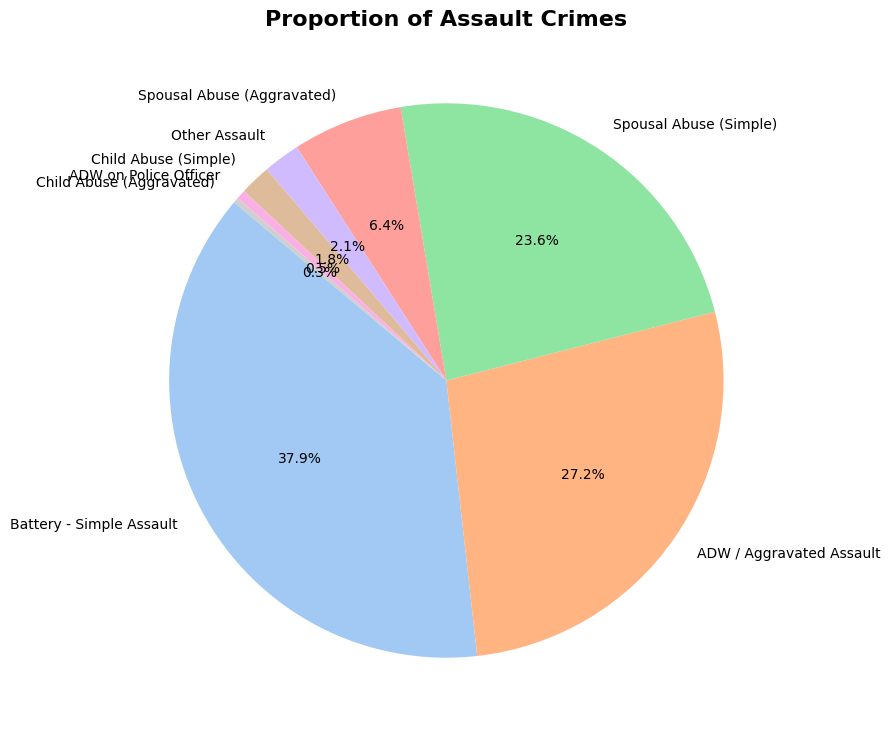

In [12]:
# Crime Severity Mix
plt.figure(figsize=(9, 9))

# Calculating counts for the pie chart
severity_counts = data['Assault Category'].value_counts()

plt.pie(severity_counts, 
        labels=severity_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('pastel')) # Slightly separates slices for clarity

plt.title('Proportion of Assault Crimes', fontsize=16, fontweight='bold')
plt.show()

Next, we examined temporal distributions, specifically the time and days of the week for which the crimes most likely occurred, to identify cyclical crime patterns in Los Angeles. This analysis is essential to pinpoint the specific high volatilty windows where the LAPD would need to increase personnel. As shown in the distribution of assaults by hour of day, there is a steady climb through the afternoon into the night, with the most common hour at 8 PM. In the distribution of assaults by day of the week, Saturday and Sunday accounts for more of the volume than other days, suggesting deployment may need to be adjusted to account for heightened weekend surge.

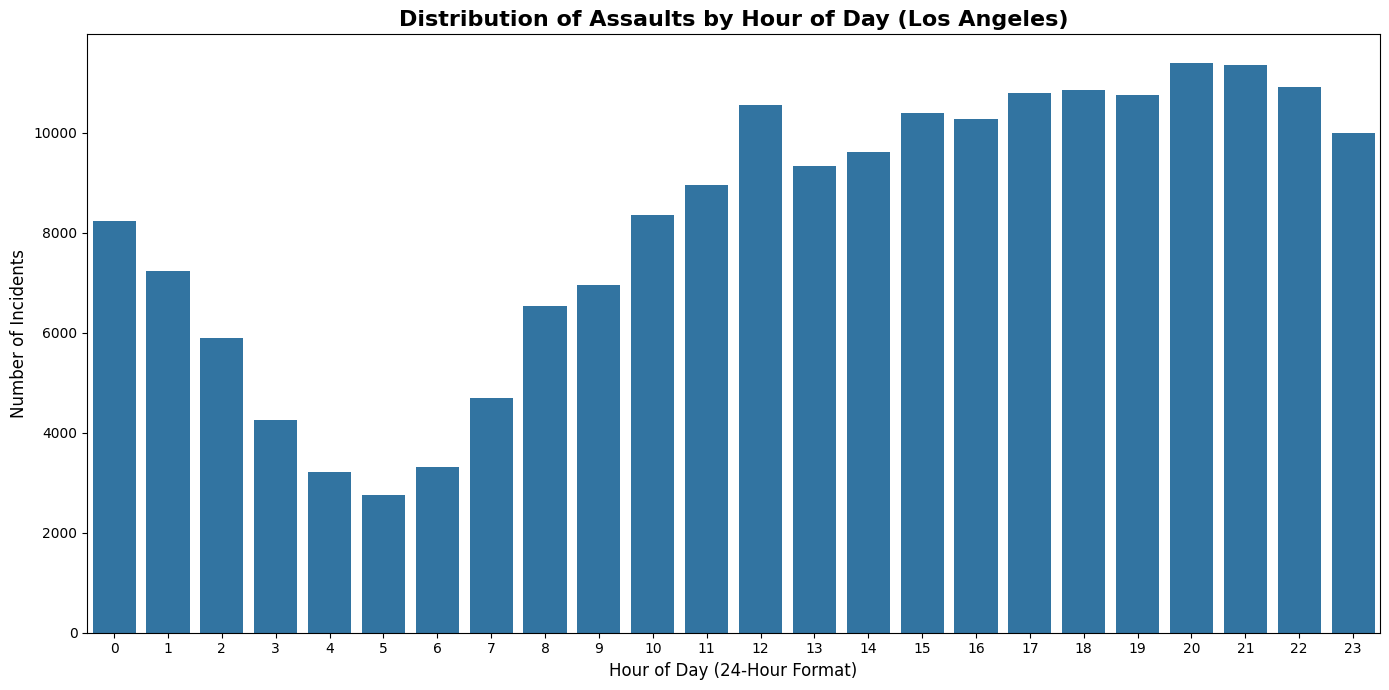

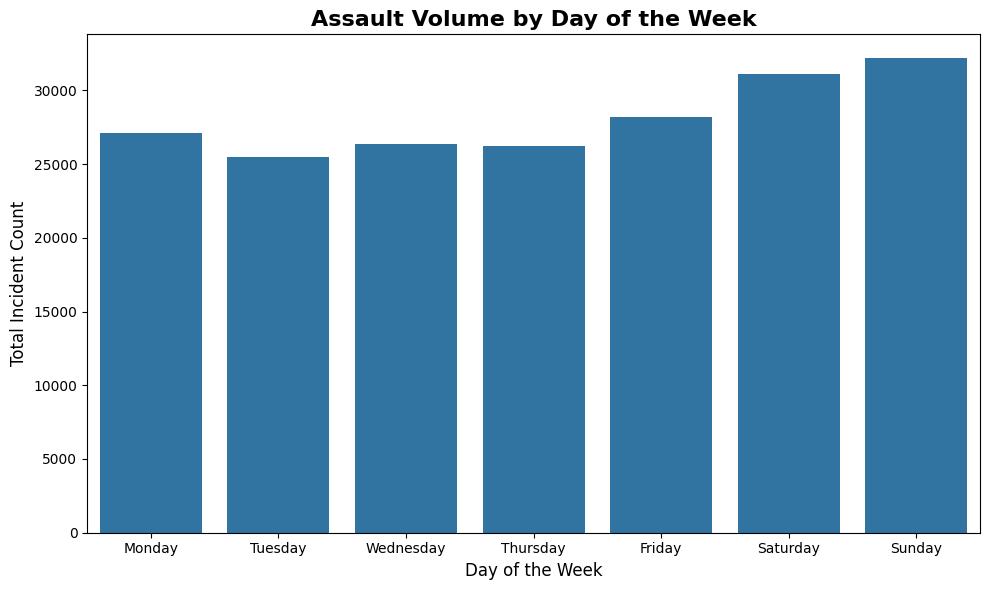

In [13]:
# Hour of Day Distribution
# Extract the hour from the time the crime occurred
data['Hour'] = pd.to_datetime(data['TIME OCC'], format='%H:%M:%S').dt.hour

plt.figure(figsize=(14, 7))
# Using a countplot to see the distribution of different assault types across the day
sns.countplot(data=data, x='Hour')

plt.title('Distribution of Assaults by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day (24-Hour Format)', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.tight_layout()
plt.show()

# Day of the Week Distribution
# Extract the day name from when the crime occurred
data['Day_of_Week'] = pd.to_datetime(data['DATE OCC']).dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
# Using a bar plot with a specific order to show the "Weekend Surge"
sns.countplot(data=data, x='Day_of_Week', order=day_order)

plt.title('Assault Volume by Day of the Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Incident Count', fontsize=12)
plt.tight_layout()
plt.show()

Then, we utilized a scatterplot to examine the physical distribution of assaults in LA. By visualizing the density of crimes, we are able to see where hotspots of crime are located. The geospatial distrubtion reveals that while there are concentrated areas, assault incidents occur throughout the entire city and forces need to be deployed properly.

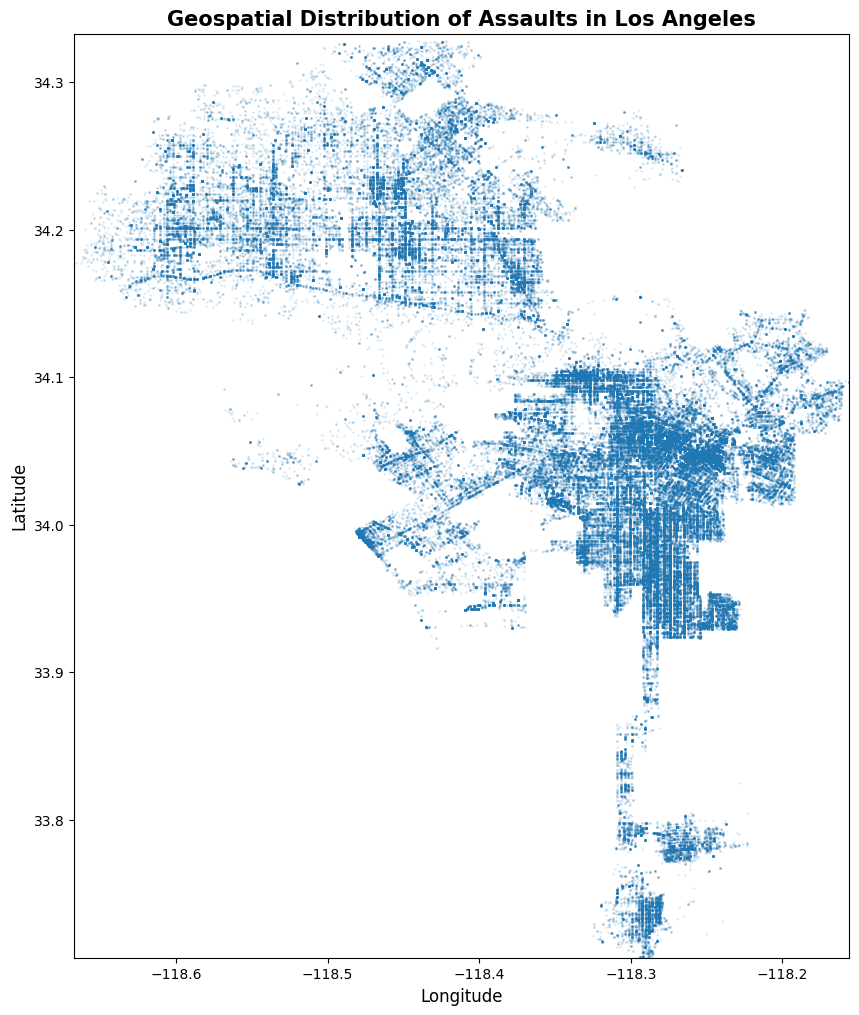

In [17]:
# Geospatial Distribution
plt.figure(figsize=(10, 12))

plt.scatter(data['LON'], data['LAT'], alpha=0.1, s=1)

plt.title('Geospatial Distribution of Assaults in Los Angeles', fontsize=15, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

plt.xlim(data['LON'].min(), data['LON'].max())
plt.ylim(data['LAT'].min(), data['LAT'].max())

plt.grid(False) # Clean look for a map-like visualization
plt.show()

### Modeling

The code and details of our modeling techniques can be found  in `models\baseline_models.ipynb`.

First, to establish a performance benchmark, we implemented a multiple linear regression model using a temporal split at the end of 2023 to prevent data leakage. The model achieved a MAE of 1.055, indicating that our model's predicted crime count for a grid cell in a given month is off by about 1 crime incident, which is reasonable. However, our RMSE is 2.386, higher than our MAE, suggesting while most predictions are fairly close to the actual value, some high crime months create large errors. This is expected because crime distributions are highly skewed. Moreover, the prediction error map reveals the regresssion can capture general trends, but struggles with the localized, non-linear high-intensity surges. The biggest takeaway from the regression is that recent crime history is the strongest predictor, validating the "near-repeat" phenomenon. This finding indicates we need to transition into non-linear machine learning models. 

Since the baseline linear regression model struggled with the non-linear spikes, we transitioned to a k-means clustering approach to identify natural groupings of crime activity. After scaling our features to ensure geographic coordinates and crime counts were weighted equally, we utilized the elbow method and silhouette scores to determine the optimal number of clusters was 4. The results revealed a clear hierarchy: Cluster 1 represents high-intensity "chronic" hotspots with an average of 18 incidents, while Clusters 0 and 2 capture moderate activity, and Cluster 3 identifies low-risk areas. The clustering method provides more information for force deployment as it separates high-frequency zones from crime surges.

### Problems & Challenges

### Next Steps

Next Steps: We started out just running a linear regression to try and understand our data and how it works. We quickly realized with our visualizations and regression results that this is not enough, we need to do something more complex. We also looked at a clustering model to see if we can identify any hotspots by unsupervised methods. We chose 4 clusters and were able to find means that have around the same crime counts. So for our next steps, we want to try running an more advanced model such as Random Forest or XGBoost to be able to handle the nonlinear relationship between the lag variables and crime counts. This would hopefully reduce the overwhelming presence over underpredicition in our current model. We would probably still incorporate clustering into our random forest model to make more accurate predicitions within each cluster.